In [1]:
# # 01 — Modeling (RF + SMOTE)
# This notebook:
# 1) Loads cleaned data (from /3. Analysis)
# 2) Prepares modeling dataset (drops leakage/EDA-only cols)
# 3) Baseline comparison (LR vs RF+SMOTE vs GB+SMOTE)
# 4) GridSearchCV on RF+SMOTE (cv=3, scoring=f1_macro)
# 5) Threshold tuning for class=1 to enforce recall_1 >= 0.75 and maximize precision_1
# 6) Saves figures + artifacts (model, results, threshold)

In [2]:
# Imports
import warnings
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay, precision_recall_curve

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline

In [3]:
# Global settings
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)
pd.set_option("display.max_columns", None)

# Seaborn theme (keep the same project look)
sns.set_theme(style="whitegrid", palette="crest")

# Paths (adjust only DATA_PATH if your filename differs)
ROOT = Path("..")  # notebook is inside "4. Modeling"
DATA_PATH = ROOT / "3. Analysis" / "weatherAUS_clean.csv"
FIG_DIR = Path(".") / "figures"
ART_DIR = Path(".") / "artifacts"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

# Presentation theme colors
BG_COLOR = "#E6DED2"
TEXT_COLOR = "#2B2B2B"

# Confusion Matrix palette 
CM_PALETTE = ["#F2EDE4", "#D9CFC1", "#A8B8A2"]  # low -> high
CM_CMAP = LinearSegmentedColormap.from_list("beige_to_sage", CM_PALETTE, N=256)

In [4]:
# Global settings
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

pd.set_option("display.max_columns", None)

# Seaborn theme (keep the same project look)
sns.set_theme(style="whitegrid", palette="crest")

# %% [code]
# Paths (adjust only DATA_PATH if your filename differs)
ROOT = Path("..")
DATA_PATH = ROOT / "1. Data" / "processed" / "weatherAUS_model_ready.csv"

FIG_DIR = Path(".") / "figures"
ART_DIR = Path(".") / "artifacts"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

# %% [code]
# Presentation theme colors
BG_COLOR = "#E6DED2"
TEXT_COLOR = "#2B2B2B"

# Confusion Matrix palette (soft beige -> sage)
CM_PALETTE = ["#F2EDE4", "#D9CFC1", "#A8B8A2"]  # low -> high
CM_CMAP = LinearSegmentedColormap.from_list("beige_to_sage", CM_PALETTE, N=256)

In [5]:
def save_fig(filename: str, dpi: int = 220):
    """Save current matplotlib figure with consistent settings."""
    plt.savefig(FIG_DIR / filename, dpi=dpi, bbox_inches="tight", facecolor=plt.gcf().get_facecolor())

In [6]:
def apply_axes_theme(ax):
    """Apply background + text styling to a matplotlib Axes."""
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)
    ax.grid(True, alpha=0.12)

In [7]:
# Load cleaned data
df_model = pd.read_csv(DATA_PATH, low_memory=False)
print("Loaded shape:", df_model.shape)
df_model.head(5)

Loaded shape: (132863, 11)


,Evaporation,Sunshine,WindGustSpeed,WindSpeed,Humidity,Pressure,Cloud,Temperature,WindGustDir,Month,RainTomorrow
0,1.600000,2.6,48.0,14.0,79.5,1017.55,6.0,14.20,NW,Jul,0
1,1.400000,7.8,35.0,14.0,63.5,1022.50,6.0,14.60,SW,Jul,0
2,1.800000,2.1,20.0,6.5,68.5,1027.15,6.0,11.60,W,Jul,0
3,1.400000,8.0,30.0,9.5,58.5,1027.15,6.0,12.75,NNE,Jul,0
4,3.533333,1.5,52.0,18.5,62.0,1017.85,6.0,13.70,NNW,Jul,1


In [8]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 132863 entries, 0 to 132862
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Evaporation    132863 non-null  float64
 1   Sunshine       132863 non-null  float64
 2   WindGustSpeed  132863 non-null  float64
 3   WindSpeed      132863 non-null  float64
 4   Humidity       132863 non-null  float64
 5   Pressure       132863 non-null  float64
 6   Cloud          132863 non-null  float64
 7   Temperature    132863 non-null  float64
 8   WindGustDir    132863 non-null  str    
 9   Month          132863 non-null  str    
 10  RainTomorrow   132863 non-null  int64  
dtypes: float64(8), int64(1), str(2)
memory usage: 11.8 MB


In [9]:
# Features
X_raw = df_model.drop(columns=['RainTomorrow']).copy()
# Target
y = df_model['RainTomorrow'].copy()

In [10]:
# Month/WindGustDir OHE 
categorical_features = ["WindGustDir", "Month"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat_ohe = pd.DataFrame(
    ohe.fit_transform(X_raw[categorical_features]),
    columns=ohe.get_feature_names_out(categorical_features),
    index=X_raw.index)
X_ohe = pd.concat([X_raw.drop(columns=categorical_features), X_cat_ohe], axis=1)

In [11]:
print("X_ohe shape:", X_ohe.shape)
X_ohe

X_ohe shape: (132863, 36)


,Evaporation,Sunshine,WindGustSpeed,WindSpeed,Humidity,Pressure,Cloud,Temperature,WindGustDir_E,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,Month_Apr,Month_Aug,Month_Dec,Month_Feb,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,1.600000,2.6,48.0,14.0,79.5,1017.55,6.000000,14.20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.400000,7.8,35.0,14.0,63.5,1022.50,6.000000,14.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.800000,2.1,20.0,6.5,68.5,1027.15,6.000000,11.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.400000,8.0,30.0,9.5,58.5,1027.15,6.000000,12.75,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.533333,1.5,52.0,18.5,62.0,1017.85,6.000000,13.70,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132858,2.200000,0.0,20.0,8.0,44.5,1027.00,3.333333,15.15,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
132859,2.000000,0.0,22.0,10.0,37.0,1026.50,3.666667,15.10,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
132860,1.400000,0.0,31.0,15.0,42.5,1024.00,7.000000,14.55,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
132861,4.000000,0.0,33.0,14.0,44.0,1019.60,5.000000,16.50,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [12]:
# Define continuous numeric columns (scale only these)
numeric_features = ["Evaporation", "Sunshine", "WindGustSpeed","WindSpeed", "Humidity", "Pressure", "Cloud", "Temperature"]
dummy_features = [c for c in X_ohe.columns if c not in numeric_features]

In [13]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_ohe, y, test_size=0.25, random_state=42, stratify=y, shuffle=True)

In [14]:
# Preprocess: scale continuous, keep dummies as-is
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("dummy", "passthrough", dummy_features)],
    remainder="drop")

print("Numeric features scaled:", numeric_features)
print("Dummy features passthrough:", len(dummy_features))

Numeric features scaled: ['Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed', 'Humidity', 'Pressure', 'Cloud', 'Temperature']
Dummy features passthrough: 28


In [15]:
# Pipelines
pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        solver="liblinear",
        max_iter=2000,
        class_weight="balanced",
        random_state=42))])

pipe_rf_smote = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1))])

pipe_gb_smote = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(
        n_estimators=500,
        random_state=42))])

models = {
    "LogisticRegression": pipe_lr,
    "RandomForest_SMOTE": pipe_rf_smote,
    "GradientBoosting_SMOTE": pipe_gb_smote}

In [16]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """
    Fit a model and return:
    - primary metrics (balanced accuracy, macro f1, macro recall, roc auc)
    - per-class precision/recall (0 and 1)
    - predictions and probabilities (for ROC / confusion matrix)
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    return {
        "model": name,
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "macro_recall": recall_score(y_test, y_pred, average="macro"),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "precision_0": rep["0"]["precision"],
        "recall_0": rep["0"]["recall"],
        "precision_1": rep["1"]["precision"],
        "recall_1": rep["1"]["recall"],
        "fitted_model": model,
        "y_pred": y_pred,
        "y_proba": y_proba}

In [ ]:
# Baseline training + evaluation
results = []
for name, model in models.items():
    results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))
results_df = (
    pd.DataFrame(results)[
        ["model","balanced_accuracy","macro_f1","macro_recall","roc_auc",
         "precision_0","recall_0","precision_1","recall_1"]]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True))

print("\nBaseline results:")
display(results_df)
results_df.to_csv(ART_DIR / "results_baseline.csv", index=False)

c:\Users\georg\miniconda3\envs\rain311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)



Baseline results:
                    model  balanced_accuracy  macro_f1  macro_recall  \
0      RandomForest_SMOTE           0.772185  0.769471      0.772185   
1  GradientBoosting_SMOTE           0.751639  0.757746      0.751639   
2      LogisticRegression           0.772384  0.722551      0.772384   

    roc_auc  precision_0  recall_0  precision_1  recall_1  
0  0.876438     0.900105  0.892936     0.633682  0.651435  
1  0.865387     0.887957  0.904883     0.641399  0.598395  
2  0.855951     0.921610  0.777327     0.494913  0.767442  


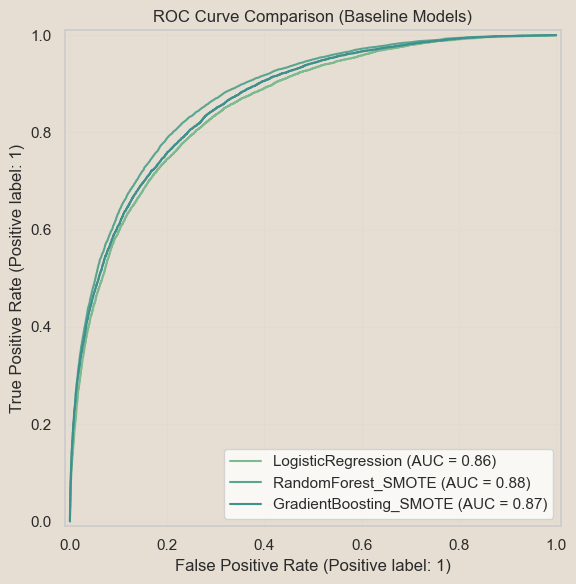

In [18]:
# ROC comparison (baselines)
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)
for r in results:
    RocCurveDisplay.from_predictions(y_test, r["y_proba"], name=r["model"], ax=ax)

ax.set_title("ROC Curve Comparison (Baseline Models)", color=TEXT_COLOR)
ax.grid(True, alpha=0.12)
ax.tick_params(colors=TEXT_COLOR)
ax.xaxis.label.set_color(TEXT_COLOR)
ax.yaxis.label.set_color(TEXT_COLOR)
leg = ax.legend()
for t in leg.get_texts():
    t.set_color(TEXT_COLOR)
plt.tight_layout()
save_fig("roc_baselines.png")
plt.show()

In [19]:
# Best baseline model (by Macro F1)
best_name = results_df.iloc[0]["model"]
best_entry = [r for r in results if r["model"] == best_name][0]
print("\nBest baseline model (by Macro F1):", best_name)


Best baseline model (by Macro F1): RandomForest_SMOTE


In [20]:
def plot_confusion_matrix_theme(y_true, y_pred, title, filename):
    """Confusion Matrix with project theme + soft colormap + non-linear normalization."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)
    # Non-linear normalization keeps low/mid cells visible
    norm = PowerNorm(gamma=0.65, vmin=cm.min(), vmax=cm.max())
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Rain", "Rain"])
    disp.plot(
        ax=ax,
        cmap=CM_CMAP,
        values_format="d",
        colorbar=True,
        im_kw={"norm": norm}    )
    ax.grid(False)
    ax.set_title(title, color=TEXT_COLOR)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    # Style the numbers inside cells
    for t in disp.text_.ravel():
        t.set_color(TEXT_COLOR)
    # Style colorbar
    cbar = disp.im_.colorbar
    cbar.ax.set_facecolor(BG_COLOR)
    cbar.ax.tick_params(colors=TEXT_COLOR)
    cbar.outline.set_edgecolor(TEXT_COLOR)
    plt.tight_layout()
    save_fig(filename)
    plt.show()

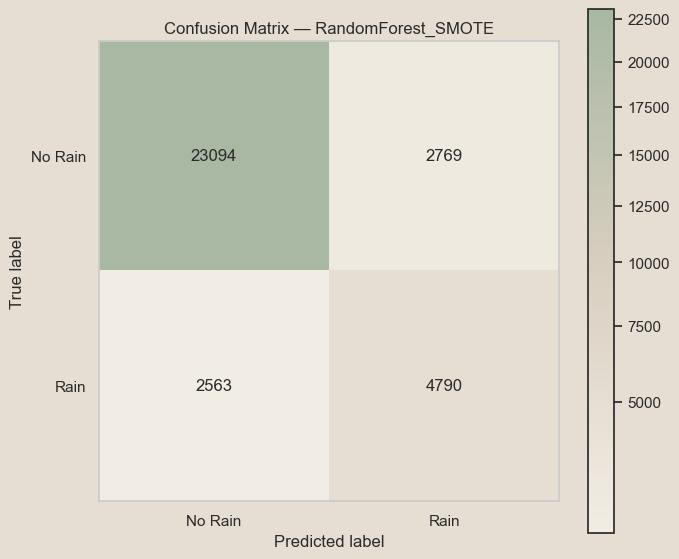

In [21]:
# Confusion Matrix for best baseline
plot_confusion_matrix_theme(
    y_test,
    best_entry["y_pred"],
    title=f"Confusion Matrix — {best_name}",
    filename="cm_baseline_best.png")

In [22]:
# GridSearchCV for RF + SMOTE (cv=3, scoring=f1_macro)
param_grid = {
    "model__n_estimators": [100, 300, 600, 1000],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.5]}

grid = GridSearchCV(estimator=pipe_rf_smote,param_grid=param_grid,scoring="f1_macro",cv=3,n_jobs=-1,verbose=2,refit=True)

In [23]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 20], 'model__max_features': ['sqrt', 0.5], 'model__min_samples_leaf': [1, 2], 'model__n_estimators': [100, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [24]:
print("GridSearch best params:", grid.best_params_)
print("GridSearch best CV score (f1_macro):", grid.best_score_)

GridSearch best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 1000}
GridSearch best CV score (f1_macro): 0.7652578416818475


In [25]:
# Evaluate tuned model on test set
tuned = grid.best_estimator_
tuned_pred = tuned.predict(X_test)
tuned_proba = tuned.predict_proba(X_test)[:, 1]
report = classification_report(y_test, tuned_pred, output_dict=True, zero_division=0)
tuned_row = {
    "model": "RandomForest_SMOTE_TUNED",
    "balanced_accuracy": balanced_accuracy_score(y_test, tuned_pred),
    "macro_f1": f1_score(y_test, tuned_pred, average="macro"),
    "macro_recall": recall_score(y_test, tuned_pred, average="macro"),
    "roc_auc": roc_auc_score(y_test, tuned_proba),
    "precision_0": report["0"]["precision"],
    "recall_0": report["0"]["recall"],
    "precision_1": report["1"]["precision"],
    "recall_1": report["1"]["recall"]}
tuned_df = pd.DataFrame([tuned_row])
print("\nTuned results:")
display(tuned_df)


Tuned results:


,model,balanced_accuracy,macro_f1,macro_recall,roc_auc,precision_0,recall_0,precision_1,recall_1
0,RandomForest_SMOTE_TUNED,0.77234,0.769729,0.77234,0.876685,0.900136,0.893245,0.634353,0.651435


In [26]:
# Combine baseline + tuned into one final table
final_results_df = (pd.concat([results_df, tuned_df], ignore_index=True).sort_values("macro_f1", ascending=False).reset_index(drop=True))
print("\nFinal results (baseline + tuned):")
display(final_results_df)

final_results_df.to_csv(ART_DIR / "results_final.csv", index=False)


Final results (baseline + tuned):


,model,balanced_accuracy,macro_f1,macro_recall,roc_auc,precision_0,recall_0,precision_1,recall_1
0,RandomForest_SMOTE_TUNED,0.772340,0.769729,0.772340,0.876685,0.900136,0.893245,0.634353,0.651435
1,RandomForest_SMOTE,0.772185,0.769471,0.772185,0.876438,0.900105,0.892936,0.633682,0.651435
2,GradientBoosting_SMOTE,0.751639,0.757746,0.751639,0.865387,0.887957,0.904883,0.641399,0.598395
3,LogisticRegression,0.772384,0.722551,0.772384,0.855951,0.921610,0.777327,0.494913,0.767442


In [ ]:
# The file was more than 3GB, so the last cell with model saving was removed to reduce size. The code is shown below for reference but is not executed in the notebook.
"""# Store tuned model as artifact
joblib.dump(tuned, ART_DIR / "rf_smote_tuned.joblib")

# Also store best params
with open(ART_DIR / "rf_smote_tuned_best_params.json", "w", encoding="utf-8") as f:
    json.dump(grid.best_params_, f, indent=2)"""
None

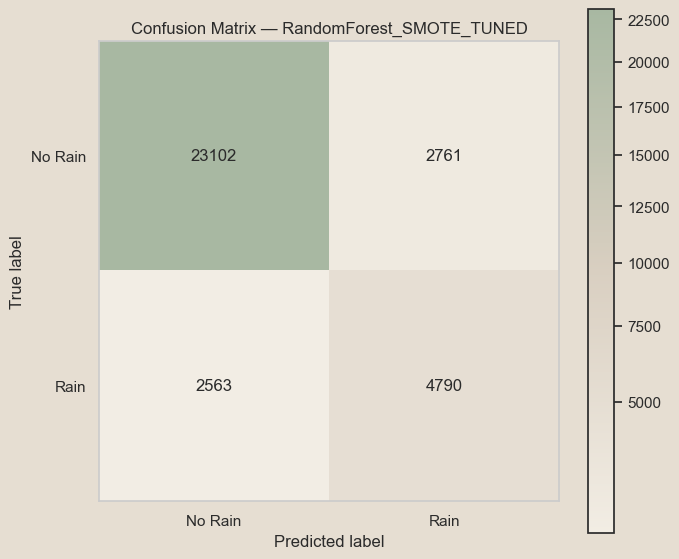

In [28]:
# Confusion Matrix for tuned model
plot_confusion_matrix_theme(
    y_test,
    tuned_pred,
    title="Confusion Matrix — RandomForest_SMOTE_TUNED",
    filename="cm_rf_tuned.png")

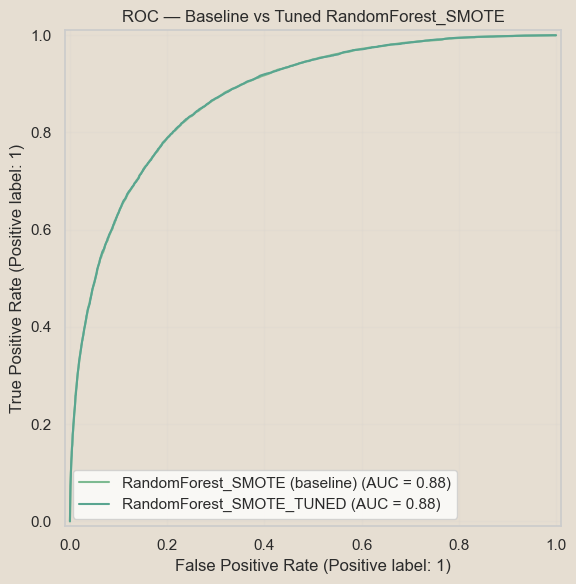

In [29]:
# ROC: baseline RF_SMOTE vs tuned
baseline_rf_entry = [r for r in results if r["model"] == "RandomForest_SMOTE"][0]
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)
RocCurveDisplay.from_predictions(y_test, baseline_rf_entry["y_proba"], name="RandomForest_SMOTE (baseline)", ax=ax)
RocCurveDisplay.from_predictions(y_test, tuned_proba, name="RandomForest_SMOTE_TUNED", ax=ax)
ax.set_title("ROC — Baseline vs Tuned RandomForest_SMOTE", color=TEXT_COLOR)
ax.grid(True, alpha=0.12)
ax.tick_params(colors=TEXT_COLOR)
ax.xaxis.label.set_color(TEXT_COLOR)
ax.yaxis.label.set_color(TEXT_COLOR)
leg = ax.legend()
for t in leg.get_texts():
    t.set_color(TEXT_COLOR)
plt.tight_layout()
save_fig("roc_rf_baseline_vs_tuned.png")
plt.show()

In [30]:
# Threshold tuning for class=1:
# Constraint: recall_1 >= 0.75, then maximize precision_1
TARGET_RECALL_1 = 0.75
prec, rec, thr = precision_recall_curve(y_test, tuned_proba)

# Align arrays (precision/recall have one extra element)
prec_t = prec[1:]
rec_t  = rec[1:]
thr_t  = thr
mask = rec_t >= TARGET_RECALL_1
if mask.any():
    best_idx = np.argmax(np.where(mask, prec_t, -1.0))
else:
    # If constraint not reachable, pick max recall point
    best_idx = np.argmax(rec_t)
best_threshold = float(thr_t[best_idx])
best_precision = float(prec_t[best_idx])
best_recall    = float(rec_t[best_idx])

print(f"Chosen threshold = {best_threshold:.6f}")
print(f"precision_1      = {best_precision:.6f}")
print(f"recall_1         = {best_recall:.6f}")
print(f"(constraint met) = {bool(mask.any())}")

Chosen threshold = 0.402000
precision_1      = 0.555254
recall_1         = 0.750986
(constraint met) = True


In [31]:
# Save threshold artifact
with open(ART_DIR / "rf_smote_threshold.json", "w", encoding="utf-8") as f:
    json.dump(
        {"threshold": best_threshold, "precision_1": best_precision, "recall_1": best_recall, "target_recall_1": TARGET_RECALL_1},
        f, indent=2)

In [32]:
# Apply threshold and evaluate
tuned_pred_thr = (tuned_proba >= best_threshold).astype(int)
report_thr = classification_report(y_test, tuned_pred_thr, output_dict=True, zero_division=0)

tuned_thr_row = {
    "model": "RandomForest_SMOTE_TUNED (thresholded)",
    "threshold": best_threshold,
    "balanced_accuracy": balanced_accuracy_score(y_test, tuned_pred_thr),
    "macro_f1": f1_score(y_test, tuned_pred_thr, average="macro"),
    "macro_recall": recall_score(y_test, tuned_pred_thr, average="macro"),
    "roc_auc": roc_auc_score(y_test, tuned_proba),  
    "precision_0": report_thr["0"]["precision"],
    "recall_0": report_thr["0"]["recall"],
    "precision_1": report_thr["1"]["precision"],
    "recall_1": report_thr["1"]["recall"]}

tuned_thr_df = pd.DataFrame([tuned_thr_row])
print("\nThresholded results:")
display(tuned_thr_df)


Thresholded results:


,model,threshold,balanced_accuracy,macro_f1,macro_recall,roc_auc,precision_0,recall_0,precision_1,recall_1
0,RandomForest_SMOTE_TUNED (thresholded),0.402,0.790055,0.755295,0.790055,0.876685,0.921525,0.828172,0.554397,0.751938


In [33]:
# Update final table 
final_results_df = (
    pd.concat([results_df, tuned_df, tuned_thr_df], ignore_index=True)
    .sort_values("macro_recall", ascending=False)
    .reset_index(drop=True))

print("\nFinal results (baseline + tuned + thresholded):")
display(final_results_df)

final_results_df.to_csv(ART_DIR / "results_final_with_threshold.csv", index=False)


Final results (baseline + tuned + thresholded):


,model,balanced_accuracy,macro_f1,macro_recall,roc_auc,precision_0,recall_0,precision_1,recall_1,threshold
0,RandomForest_SMOTE_TUNED (thresholded),0.790055,0.755295,0.790055,0.876685,0.921525,0.828172,0.554397,0.751938,0.402
1,LogisticRegression,0.772384,0.722551,0.772384,0.855951,0.921610,0.777327,0.494913,0.767442,NaN
2,RandomForest_SMOTE_TUNED,0.772340,0.769729,0.772340,0.876685,0.900136,0.893245,0.634353,0.651435,NaN
3,RandomForest_SMOTE,0.772185,0.769471,0.772185,0.876438,0.900105,0.892936,0.633682,0.651435,NaN
4,GradientBoosting_SMOTE,0.751639,0.757746,0.751639,0.865387,0.887957,0.904883,0.641399,0.598395,NaN


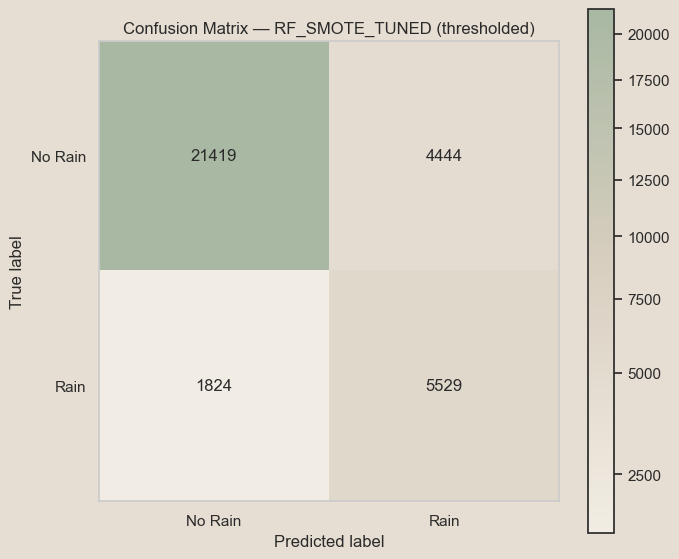

In [34]:
# Confusion Matrix for thresholded predictions
plot_confusion_matrix_theme(
    y_test,
    tuned_pred_thr,
    title="Confusion Matrix — RF_SMOTE_TUNED (thresholded)",
    filename="cm_rf_thresholded.png")

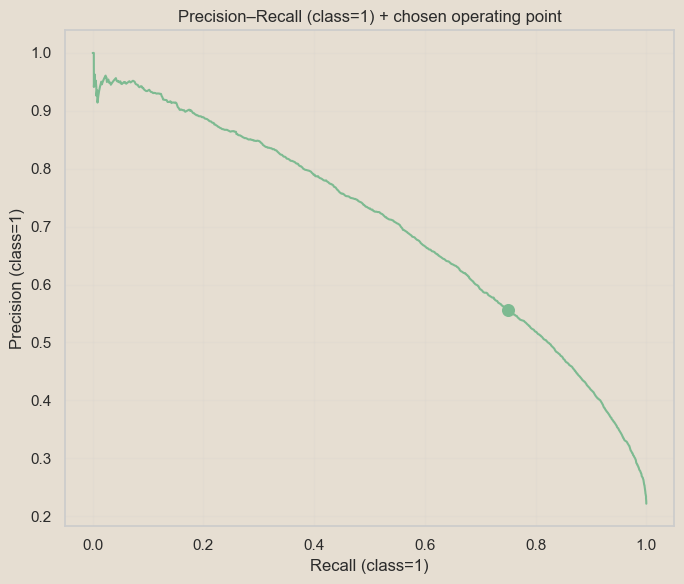

In [35]:
# Precision-Recall curve + chosen operating point
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.plot(rec, prec)
ax.scatter(best_recall, best_precision, s=70)
ax.set_title("Precision–Recall (class=1) + chosen operating point", color=TEXT_COLOR)
ax.set_xlabel("Recall (class=1)")
ax.set_ylabel("Precision (class=1)")
apply_axes_theme(ax)
plt.tight_layout()
save_fig("pr_threshold_choice.png")
plt.show()